CSV caricato: 480 righe
Dati finali: 448 righe
Anni: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]

=== MEDIA PER ANNO ===
   Anno      Media
0  2020   7.313393
1  2021  16.415179
2  2022  16.075893
3  2023  13.308036


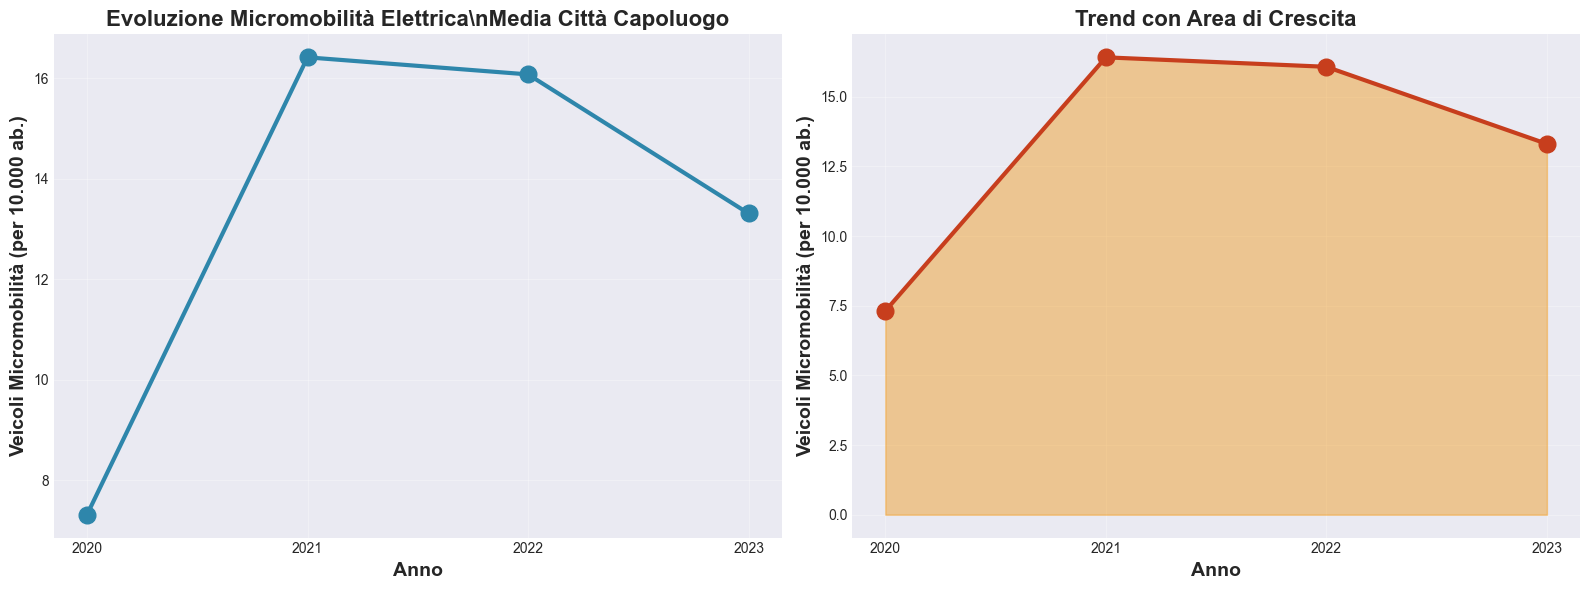

In [3]:
# ============================================================================
# SCRIPT JUPYTER NOTEBOOK - ANALISI AUTOVETTURE ELETTRICHE IN ITALIA
# ============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configurazione stile
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# ============================================================================
# 1. CARICA IL CSV
# ============================================================================
df = pd.read_csv('../data/csv/dati_veicoli_micromobilita_elettrica_per_10k_abitanti.csv')

print(f"CSV caricato: {len(df)} righe")

# 2. RESET DEL MULTIINDEX (QUESTO È IL TRUCCO!)
df = df.reset_index()

# 2. FILTRA LE AGGREGAZIONI TERRITORIALI
valori_da_escludere = [
    'Italia', 'Nord', 'Nord-ovest', 'Nord-Ovest', 
    'Nord-est', 'Nord-Est', 'Centro', 'Sud', 'Isole', 'Mezzogiorno'
]

# Usa level_3 che contiene i nomi dei territori
df_filtrato = df[~df['level_3'].isin(valori_da_escludere)].copy()

df_filtrato = df[~df['level_3'].isin(valori_da_escludere)].copy()

# 3. USA FREQUENZA (ANNI) E REF_AREA (VALORI)!!!
df_clean = df_filtrato[['Frequenza', 'REF_AREA']].copy()
df_clean.columns = ['Anno', 'Valore']

# 4. CONVERTI
df_clean['Anno'] = pd.to_numeric(df_clean['Anno'], errors='coerce')
df_clean['Valore'] = pd.to_numeric(df_clean['Valore'], errors='coerce')
df_clean = df_clean.dropna()

print(f"Dati finali: {len(df_clean)} righe")
print(f"Anni: {sorted(df_clean['Anno'].unique())}")

# 5. CALCOLA MEDIA
media_per_anno = df_clean.groupby('Anno')['Valore'].mean().reset_index()
media_per_anno.columns = ['Anno', 'Media']

print("\n=== MEDIA PER ANNO ===")
print(media_per_anno)

# 6. GRAFICI
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Grafico 1
ax1.plot(media_per_anno['Anno'], media_per_anno['Media'], 
         marker='o', linewidth=3, markersize=12, color='#2E86AB')
ax1.set_xlabel('Anno', fontsize=14, fontweight='bold')
ax1.set_ylabel('Veicoli Micromobilità (per 10.000 ab.)', fontsize=14, fontweight='bold')
ax1.set_title('Evoluzione Micromobilità Elettrica\\nMedia Città Capoluogo', 
              fontsize=16, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(media_per_anno['Anno'].astype(int))

# Grafico 2
ax2.fill_between(media_per_anno['Anno'], media_per_anno['Media'], alpha=0.4, color='#F18F01')
ax2.plot(media_per_anno['Anno'], media_per_anno['Media'], 
         marker='o', linewidth=3, markersize=12, color='#C73E1D')
ax2.set_xlabel('Anno', fontsize=14, fontweight='bold')
ax2.set_ylabel('Veicoli Micromobilità (per 10.000 ab.)', fontsize=14, fontweight='bold')
ax2.set_title('Trend con Area di Crescita', fontsize=16, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(media_per_anno['Anno'].astype(int))


plt.tight_layout()
plt.show()



In [1]:
# ============================================================================
# CONFRONTO TRA DUE DATASET
# ============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================================================
# FUNZIONE PER PROCESSARE I DATI
# ============================================================================
def carica_e_processa_csv(file_path, nome_dataset):
    """Carica un CSV ISTAT e restituisce la media per anno"""
    df = pd.read_csv(file_path)
    df = df.reset_index()
    
    # Filtra aggregazioni
    valori_da_escludere = [
        'Italia', 'Nord', 'Nord-ovest', 'Nord-Ovest', 
        'Nord-est', 'Nord-Est', 'Centro', 'Sud', 'Isole', 'Mezzogiorno'
    ]
    
    df_filtrato = df[~df['level_3'].isin(valori_da_escludere)].copy()
    df_clean = df_filtrato[['Frequenza', 'REF_AREA']].copy()
    df_clean.columns = ['Anno', 'Valore']
    
    df_clean['Anno'] = pd.to_numeric(df_clean['Anno'], errors='coerce')
    df_clean['Valore'] = pd.to_numeric(df_clean['Valore'], errors='coerce')
    df_clean = df_clean.dropna()
    
    media_per_anno = df_clean.groupby('Anno')['Valore'].mean().reset_index()
    media_per_anno.columns = ['Anno', 'Media']
    
    print(f"\n{nome_dataset}: {len(df_clean)} righe - Anni: {sorted(df_clean['Anno'].unique())}")
    
    return media_per_anno

# ============================================================================
# CARICA I DUE DATASET
# ============================================================================

file1 = '../data/csv/dati_veicoli_micromobilita_elettrica_per_10k_abitanti.csv'
dataset1 = carica_e_processa_csv(file1, "Micromobilità")

file2 = '../data/csv/altro_dataset.csv'  # <-- MODIFICA CON IL TUO FILE
dataset2 = carica_e_processa_csv(file2, "Dataset 2")

print("\n=== DATASET 1 ===")
print(dataset1)
print("\n=== DATASET 2 ===")
print(dataset2)

# ============================================================================
# GRAFICI CON CONFRONTO
# ============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# GRAFICO 1: LINEE SOVRAPPOSTE
ax1.plot(dataset1['Anno'], dataset1['Media'], 
         marker='o', linewidth=3, markersize=10, color='#2E86AB',
         label='Micromobilità Elettrica')

ax1.plot(dataset2['Anno'], dataset2['Media'], 
         marker='s', linewidth=3, markersize=10, color='#C73E1D',
         label='Dataset 2', linestyle='--')

ax1.set_xlabel('Anno', fontsize=14, fontweight='bold')
ax1.set_ylabel('Valore Medio (per 10.000 ab.)', fontsize=14, fontweight='bold')
ax1.set_title('Confronto Evoluzione Temporale', fontsize=16, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(dataset1['Anno'].astype(int))
ax1.legend(fontsize=12, loc='best')

# GRAFICO 2: AREE SOVRAPPOSTE
ax2.fill_between(dataset1['Anno'], dataset1['Media'], alpha=0.3, color='#2E86AB')
ax2.plot(dataset1['Anno'], dataset1['Media'], 
         marker='o', linewidth=3, markersize=10, color='#2E86AB',
         label='Micromobilità')

ax2.fill_between(dataset2['Anno'], dataset2['Media'], alpha=0.3, color='#F18F01')
ax2.plot(dataset2['Anno'], dataset2['Media'], 
         marker='s', linewidth=3, markersize=10, color='#C73E1D',
         label='Dataset 2', linestyle='--')

ax2.set_xlabel('Anno', fontsize=14, fontweight='bold')
ax2.set_ylabel('Valore Medio (per 10.000 ab.)', fontsize=14, fontweight='bold')
ax2.set_title('Confronto con Aree', fontsize=16, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(dataset1['Anno'].astype(int))
ax2.legend(fontsize=11, loc='best')

plt.tight_layout()
plt.savefig('../output/confronto.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# STATISTICHE COMPARATIVE
# ============================================================================
confronto = dataset1.merge(dataset2, on='Anno', suffixes=('_DS1', '_DS2'))
confronto['Differenza'] = confronto['Media_DS1'] - confronto['Media_DS2']

print("\n=== CONFRONTO ANNO PER ANNO ===")
print(confronto)



Micromobilità: 448 righe - Anni: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


FileNotFoundError: [Errno 2] No such file or directory: '../data/csv/altro_dataset.csv'